# Quantum Computing Algorithms and Applications
## Homework #1


### Problem 1

[[The effect of data encoding on the expressive power of variational quantum machine learning models]("https://arxiv.org/abs/2008.08605")](Ref. [1]) has shown that data reuploading circuit can be naturally interpretable as partial fourier series.

Please read Ref. [1] for the details and read [[Quantum models as Fourier series]("https://pennylane.ai/qml/demos/tutorial_expressivity_fourier_series")](Ref. [2]) for the code implementation. In Ref. [1], they
have also discussed the case of fitting a multivariate function. Let’s consider a simple case of fitting
a bivariate function. Given a target function:

$$f(x_1, x_2) = \sin(e^{x_1} + x_2)$$

Try to train a quantum machine learning model based on data reuploading circuit with $x_1, x_2 \in [0, 0.5]$,
and test on $x_1, x_2 \in [0.5, 1]$.

Here is sample code to generate the training data:

In [32]:
import numpy as np
import torch

seed = 90921008  # replace with your student ID
np.random.seed(seed)
torch.manual_seed(seed)


def target_func(x):
    return torch.sin(torch.exp(x[:, 0]) + x[:, 1])

n_samples = 100

train_input = torch.zeros(n_samples, 2)  # 1000 samples , 2 variables
train_ranges = np.array([0, 0.5] * 2).reshape(2, 2)
test_input = torch.zeros(n_samples, 2)
test_ranges = np.array([0.5, 1] * 2).reshape(2, 2)
for i in range(2):
    train_input[:, i] = (
        torch.rand(
            n_samples,
        )
        * (train_ranges[i, 1] - train_ranges[i, 0])
        + train_ranges[i, 0]
    )
    test_input[:, i] = (
        torch.rand(
            n_samples,
        )
        * (test_ranges[i, 1] - test_ranges[i, 0])
        + test_ranges[i, 0]
    )

train_label = target_func(train_input)
test_label = target_func(test_input)


In [33]:
# Convert to numpy for PennyLane
train_x = train_input.numpy()
train_y = train_label.numpy()
test_x = test_input.numpy()
test_y = test_label.numpy()

Evaluate the model with mean squared error (MSE). Try to find the best hyperparameters of the model, such as the number of layers or the number of qubits, to make the test loss lower than $0.1$.

Janus 分析:

畫出 $f(x_1, x_2) = \sin(e^{x_1} + x_2)$

In [34]:
import plotly.graph_objects as go
import numpy as np
import plotly.colors
import torch

x1 = np.linspace(0, 1, 100)
x2 = np.linspace(0, 1, 100)
X1, X2 = np.meshgrid(x1, x2)
grid = torch.tensor(np.stack([X1.ravel(), X2.ravel()], axis=1), dtype=torch.float32)
Z = target_func(grid).numpy().reshape(X1.shape)

fig = go.Figure(
    go.Surface(x=x1, y=x2, z=Z, colorscale=plotly.colors.sequential.Viridis)
)
fig.update_layout(
    template="plotly_dark",
    title=dict(text="Target function"),
    scene=dict(xaxis_title="x1", yaxis_title="x2", zaxis_title="f"),
)
fig.show()


#### (a) Plot the training loss and test loss versus epoch for your best model configuration.

##### 看看有沒有 GPU

###### PyTorch

In [35]:
import torch

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU count: {torch.cuda.device_count()}")
print(f"GPU name: {torch.cuda.get_device_name(0)}")
print(f"Current device: {torch.cuda.current_device()}")

CUDA available: True
GPU count: 1
GPU name: Tesla T4
Current device: 0


###### PennyLane

In [36]:
import pennylane as qml

pl_qml_gpu_dev = "lightning.gpu"

try:
    dev = qml.device(pl_qml_gpu_dev, wires=2)
    print(f"✅ {pl_qml_gpu_dev}: OK")
except Exception as e:
    print(f"❌ lightning.gpu: {e}")

✅ lightning.gpu: OK


##### 建 model

In [37]:
from pennylane.templates import StronglyEntanglingLayers

# Quantum model setup
n_qubits = 3
n_layers = 1  # number of data reuploading layers
n_ansatz_layers = 1  # layers in StronglyEntanglingLayers

pl_qml_gpu_dev = "lightning.gpu"
# pl_qml_gpu_dev = "default.qubit"

dev = qml.device(pl_qml_gpu_dev, wires=n_qubits)

def S(x):
    """Data encoding"""
    qml.RX(x[0], wires=0)
    qml.RX(x[1], wires=1)
    qml.RX(x[0] + x[1], wires=2)  # encode combination

def W(theta):
    """Trainable block"""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model(weights, x):
    for i in range(n_layers):
        W(weights[i])
        S(x)
    W(weights[-1])  # final W
    return qml.expval(qml.PauliZ(wires=0))

In [52]:
# Quantum model setup
n_qubits = 3
n_layers = 1  # number of data reuploading layers
n_ansatz_layers = 2  # layers in StronglyEntanglingLayers

pl_qml_gpu_dev = "lightning.gpu"
# pl_qml_gpu_dev = "default.qubit"

dev = qml.device(pl_qml_gpu_dev, wires=n_qubits)

def S(x):
    """Data encoding"""
    qml.RX(x[0], wires=0)
    qml.RX(x[1], wires=1)
    qml.RX(x[0] + x[1], wires=2)  # encode combination

def W(theta):
    """Trainable block"""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))

@qml.qnode(dev)
def quantum_model(weights, x):
    for i in range(n_layers):
        W(weights[i])
        S(x)
    W(weights[-1])  # final W
    return qml.expval(qml.PauliZ(wires=0))


In [39]:
# Quantum model setup
# n_qubits = 2
# n_layers = 2  # number of data reuploading layers
# n_ansatz_layers = 2  # layers in StronglyEntanglingLayers
# 
# pl_qml_gpu_dev = "lightning.gpu"
# # pl_qml_gpu_dev = "default.qubit"
# 
# dev = qml.device(pl_qml_gpu_dev, wires=n_qubits)
# 
# def S(x):
#     """Data encoding"""
#     qml.RX(x[0], wires=0)
#     qml.RX(x[1], wires=1)
#     # qml.RX(x[0] + x[1], wires=2)  # encode combination
# 
# def W(theta):
#     """Trainable block"""
#     StronglyEntanglingLayers(theta, wires=range(n_qubits))
# 
# @qml.qnode(dev)
# def quantum_model(weights, x):
#     for i in range(n_layers):
#         W(weights[i])
#         S(x)
#     W(weights[-1])  # final W
#     return qml.expval(qml.PauliZ(wires=0))
# 
# 

* n_qubits = 3
* n_layers = 1  # number of data reuploading layers
* n_ansatz_layers = 2  # layers in StronglyEntanglingLayers

<blockquote>
 Step 10: Train MSE = 0.0038, Test MSE = 0.3691

 Step 20: Train MSE = 0.0005, Test MSE = 0.1298

 Step 30: Train MSE = 0.0025, Test MSE = 0.1193

 Step 40: Train MSE = 0.0006, Test MSE = 0.1118

 Step 50: Train MSE = 0.0003, Test MSE = 0.1195

 Step 60: Train MSE = 0.0002, Test MSE = 0.0986

 Step 70: Train MSE = 0.0002, Test MSE = 0.1071

 Step 80: Train MSE = 0.0001, Test MSE = 0.1055

 Step 90: Train MSE = 0.0001, Test MSE = 0.0996

 Step 100: Train MSE = 0.0001, Test MSE = 0.0970

 Step 110: Train MSE = 0.0001, Test MSE = 0.0847

 Step 120: Train MSE = 0.0001, Test MSE = 0.0835

 Step 130: Train MSE = 0.0001, Test MSE = 0.0815

 Step 140: Train MSE = 0.0001, Test MSE = 0.0832
</blockquote>

###### Show model


QML model topology (ASCII):
0: ──RZ(0.00)──RY(0.00)──RZ(0.00)─╭●────╭X──RZ(0.00)──RY(0.00)──RZ(0.00)─╭●─╭X──RX(0.10) ···
1: ──RZ(0.00)──RY(0.00)──RZ(0.00)─╰X─╭●─│───RZ(0.00)──RY(0.00)──RZ(0.00)─│──╰●─╭X─────── ···
2: ──RZ(0.00)──RY(0.00)──RZ(0.00)────╰X─╰●──RZ(0.00)──RY(0.00)──RZ(0.00)─╰X────╰●─────── ···

0: ··· ──RZ(0.00)──RY(0.00)──RZ(0.00)───────────╭●────╭X──RZ(0.00)──RY(0.00)──RZ(0.00)─╭●─╭X────┤ ···
1: ··· ──RX(0.20)──RZ(0.00)──RY(0.00)──RZ(0.00)─╰X─╭●─│───RZ(0.00)──RY(0.00)──RZ(0.00)─│──╰●─╭X─┤ ···
2: ··· ──RX(0.30)──RZ(0.00)──RY(0.00)──RZ(0.00)────╰X─╰●──RZ(0.00)──RY(0.00)──RZ(0.00)─╰X────╰●─┤ ···

0: ···   <Z>
1: ···      
2: ···      


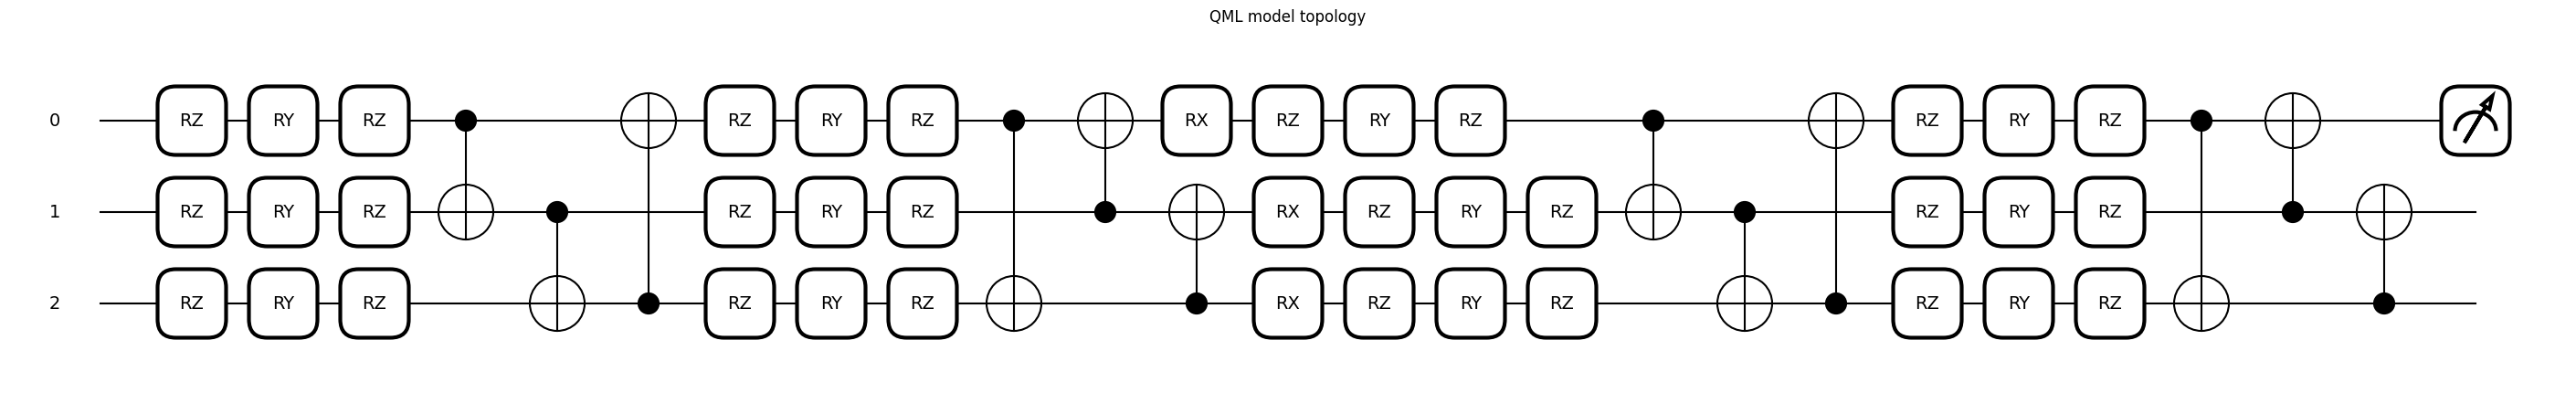

In [53]:
from pennylane import numpy as pnp

# Show model topology (text + optional plot)
weights_shape = (n_layers + 1, n_ansatz_layers, n_qubits, 3)
dummy_weights = pnp.zeros(weights_shape)
dummy_x = pnp.array([0.1, 0.2])

print("\nQML model topology (ASCII):")
print(qml.draw(quantum_model, level="device")(dummy_weights, dummy_x))

try:
    import matplotlib.pyplot as plt

    fig, ax = qml.draw_mpl(quantum_model, level="device")(dummy_weights, dummy_x)
    ax.set_title("QML model topology")
    plt.show()
except Exception as e:
    print(f"[Topology plot skipped] {e}")


##### Train model

In [54]:
# Initialize weights
weights = 2 * pnp.pi * pnp.random.random(size=weights_shape, requires_grad=True)

# Loss function
def mse_loss(predictions, targets):
    return pnp.mean((predictions - targets) ** 2)

def cost(weights, x, y):
    predictions = pnp.array([quantum_model(weights, x_i) for x_i in x])
    return mse_loss(predictions, y)

# Optimizer
opt = qml.AdamOptimizer(stepsize=0.3)
max_steps = 200
batch_size = 50

train_losses = []
test_losses = []

for step in range(max_steps):
    # Select batch
    batch_idx = pnp.random.randint(0, len(train_x), batch_size)
    x_batch = train_x[batch_idx]
    y_batch = train_y[batch_idx]

    # Update weights
    weights = opt.step(lambda w: cost(w, x_batch, y_batch), weights)

    if (step + 1) % 10 == 0:
        train_loss = cost(weights, train_x, train_y)
        test_loss  = cost(weights, test_x,  test_y)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        print(f"Step {step+1}: Train MSE = {train_loss:.4f}, Test MSE = {test_loss:.4f}")

# Final evaluation
final_train_mse = cost(weights, train_x, train_y)
final_test_mse = cost(weights, test_x, test_y)
print(f"Final Train MSE: {final_train_mse:.4f}")
print(f"Final Test MSE: {final_test_mse:.4f}")

# Number of trainable parameters
n_params = pnp.prod(pnp.array(weights_shape))
print(f"Number of trainable parameters: {n_params}")

Step 10: Train MSE = 0.0084, Test MSE = 0.2072
Step 20: Train MSE = 0.0014, Test MSE = 0.2544
Step 30: Train MSE = 0.0010, Test MSE = 0.2811
Step 40: Train MSE = 0.0009, Test MSE = 0.4177
Step 50: Train MSE = 0.0009, Test MSE = 0.3907
Step 60: Train MSE = 0.0008, Test MSE = 0.3864
Step 70: Train MSE = 0.0007, Test MSE = 0.3681
Step 80: Train MSE = 0.0006, Test MSE = 0.3225
Step 90: Train MSE = 0.0005, Test MSE = 0.2898
Step 100: Train MSE = 0.0005, Test MSE = 0.2435
Step 110: Train MSE = 0.0004, Test MSE = 0.2440
Step 120: Train MSE = 0.0003, Test MSE = 0.2095
Step 130: Train MSE = 0.0003, Test MSE = 0.1675
Step 140: Train MSE = 0.0002, Test MSE = 0.1484
Step 150: Train MSE = 0.0002, Test MSE = 0.1412
Step 160: Train MSE = 0.0002, Test MSE = 0.1195
Step 170: Train MSE = 0.0002, Test MSE = 0.0928
Step 180: Train MSE = 0.0001, Test MSE = 0.0960
Step 190: Train MSE = 0.0001, Test MSE = 0.0957
Step 200: Train MSE = 0.0001, Test MSE = 0.0785
Final Train MSE: 0.0001
Final Test MSE: 0.0785
Nu

#### (b) Provide a comparison table of at least 4 different hyperparameter configurations (e.g., number of layers, number of qubits, encoding gate type), reporting train MSE, test MSE, and the number of trainable parameters for each. 

#### (c) Compute and plot the Fourier spectrum of both the target function and your trained model’s output over the test domain. Discuss which frequency components your model captures and how this relates to the circuit depth, referencing the analysis in Ref. [1].

### Problem 2

In the class we have discussed about explicit quantum model, implicit quantum kernel method
and data reuploading circuit. There is also a paper to discuss the performance of these three methods
on regression tasks [3]. Now, let’s consider classification tasks. Follow Ref. [4], which has already
implemented data reuploading circuit, try to implement explicit quantum model and implicit quantum
kernel method (see Appendix C for a brief overview) and compare the performance of these three
methods on two datasets:

* The `circle dataset` (as used in Ref. [4])
* The `moons dataset` from scikit-learn (`sklearn.datasets.make moons with noise=0.1, n samples=200`).

Please include the following in your report:

#### (a) Try to obtain Fig. 6 in Ref. [3] with the performance on the circle dataset.

#### (b) Plot the decision boundaries of all three methods on both datasets (6 plots total, arranged as a 3 × 2 grid).

#### (c) Provide a comparison table reporting, for each method on each dataset: test accuracy, number of trainable parameters (or kernel evaluations), and training time.

#### (d) Write a brief discussion (3–5 sentences) comparing the three methods across both datasets. Relate your findings to the arguments in Ref. [3].

### Problem 3

Convolutional neural networks (CNNs) are widely used in image classification tasks. Usually, a CNN extracts spatial features and passes them to a fully connected network, especially a multi-layer perceptron (MLP) as representation learning head, for classification. An alternative approach is to replace the MLP head with a parameterized quantum circuit (PQC), creating a hybrid classical-quantum model [5, 6, 7]. The overall pipeline of such a hybrid model is illustrated below: